# Documentation
**Author:** Spencer Ressel

**Created:** May 26th, 2026

**Inputs:**     
* Global 2.5° x 2.5° resolution, daily timeseries in netCDF format:
    - outgoing longwave radiation (OLR) data from *Liebmann and Smith (1996)*

# Imports

In [ ]:
import os

from pathlib import Path
home_directory = Path.home()
os.chdir(f"{home_directory}/thesis-work-link/python/mjo_data_analysis/")

import logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
)
logger = logging.getLogger(__name__)

# Data processing tools
import numpy as np
import scipy
import scipy.signal as signal
from scipy.optimize import curve_fit
import xarray as xr
import xeofs

import sys
from auxiliary_functions.plotting_utils import modified_colormap
from auxiliary_functions import xarray_utils
from auxiliary_functions.mjo_mean_state_diagnostics import remove_annual_cycle, lanczos_bandpass_filter

# Plotting
from tqdm import tqdm
from matplotlib import pyplot as plt
from matplotlib import ticker as mticker
from matplotlib import colors as mcolors
from matplotlib.gridspec import GridSpec
from matplotlib.animation import FuncAnimation

# Cartopy
from cartopy import crs as ccrs
from cartopy import feature as cf
from cartopy import util as cutil
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter, LongitudeLocator, LatitudeLocator

# Seaborn
import seaborn as sns

# Set Physical Constants and Analysis Parameters

In [ ]:
# Set time bounds
TIME_MIN = '1974-06-01T00:00:00.000000000'
TIME_MAX = '2005-12-31T00:00:00.000000000'
# TIME_MAX = '2001-12-31T00:00:00.000000000'
# TIME_MIN = '1999-01-01T00:00:00.000000000'
# TIME_MIN = '1990-01-01T00:00:00.000000000'
# TIME_MAX = '1995-12-31T00:00:00.000000000'

missing_days = np.arange(np.datetime64("1978-03-17"), np.datetime64("1978-12-31"))

SAMPLING_FREQUENCY = 1

# Set latitude bounds
LATITUDE_SOUTH = -25
LATITUDE_NORTH = 25

# Set central longitude
CENTRAL_LONGITUDE = 160

# Set longitude bounds
LONGITUDE_MIN = 0
LONGITUDE_MAX = 360

# Cut-off periods for intraseasonal filtering
INTRASEASONAL_LOWCUT = 200
INTRASEASONAL_HIGHCUT = 20

# Seconds per day
SECONDS_PER_DAY = 24 * 3600

# Load Data

In [ ]:
variables_to_load = [
    # 'Precipitation',
    'Outgoing Longwave Radiation',
    # 'Zonal Wind',
    # 'Meridional Wind'
]

In [ ]:
logger.info("Load Variables")
# TRMM Precipitation
if 'Precipitation' in variables_to_load:
    logger.info("    Precipitation...")
    data_directory_precip = r"/home/disk/eos7/sressel/research/data/NASA/TRMM/"
    file_name_precip = "trmm_precipitation_daily_1998_2018.nc"
    data_precipitation = xr.open_dataset(
        data_directory_precip + file_name_precip, engine="netcdf4"
    )
    precipitation = data_precipitation['precipitation'].sortby('lat')

# NASA OLR (Liebmann and Smith 1996)
if 'Outgoing Longwave Radiation' in variables_to_load:
    logger.info("    Outgoing Longwave Radiation...")
    data_directory_olr = r"/home/disk/eos7/sressel/research/data/NOAA/"
    file_name_olr = "olr.day.mean.nc"
    data_olr = xr.open_dataset(data_directory_olr + file_name_olr, engine="netcdf4")
    outgoing_longwave_radiation = data_olr['olr'].sortby('lat')

# ERA5 Zonal Wind
if 'Zonal Wind' in variables_to_load:
    logger.info("    Zonal Wind...")
    data_directory_zonal_wind = r"/home/disk/p/sressel/eos7-link/research/data/ECMWF/ERA5/daily_data/25_degree_data"
    file_name_zonal_wind = "daily_25_degree_zonal_wind_1980_2018.nc"
    data_zonal_wind = xr.open_dataset(f"{data_directory_zonal_wind}/{file_name_zonal_wind}", engine="netcdf4"
    )

    zonal_wind = data_zonal_wind["u"].sortby('lat')
    zonal_wind_longitudes = zonal_wind["lon"].values
    zonal_wind_longitudes[zonal_wind_longitudes < 0] += 360
    zonal_wind["lon"] = zonal_wind_longitudes
    zonal_wind = zonal_wind.sortby(zonal_wind.lon)

    upper_level_zonal_wind = zonal_wind.sel(plev=200)
    lower_level_zonal_wind = zonal_wind.sel(plev=850)

# ERA5 Meridional Wind
if 'Meridional Wind' in variables_to_load:
    logger.info("    Meridional Wind...")
    data_directory_meridional_wind = r"/home/disk/eos7/sressel/research/data/ECMWF/ERA5/daily_data/25_degree_data"
    file_name_meridional_wind = (
        "daily_25_degree_meridional_wind_1980_2018.nc"
    )
    data_meridional_wind = xr.open_dataset(f"{data_directory_meridional_wind}/{file_name_meridional_wind}", engine="netcdf4"
    )

    meridional_wind = data_meridional_wind["v"].sortby('lat')
    meridional_wind_longitudes = meridional_wind["lon"].values
    meridional_wind_longitudes[meridional_wind_longitudes < 0] += 360
    meridional_wind["lon"] = meridional_wind_longitudes
    meridional_wind = meridional_wind.sortby(meridional_wind.lon)

    upper_level_meridional_wind = meridional_wind.sel(plev=200)
    lower_level_meridional_wind = meridional_wind.sel(plev=850)

time = outgoing_longwave_radiation.time
latitude = outgoing_longwave_radiation.lat
longitude = outgoing_longwave_radiation.lon


variables_dict = {
    # 'Precipitation' : precipitation,
    'Outgoing Longwave Radiation' : outgoing_longwave_radiation,
    # 'Upper Level Zonal Wind' : upper_level_zonal_wind,
    # 'Lower Level Zonal Wind' : lower_level_zonal_wind,
    # 'Upper Level Meridional Wind' : upper_level_meridional_wind,
    # 'Lower Level Meridional Wind' : lower_level_meridional_wind,
}
logger.info("Finished")

2026-05-26 10:47:23,692 [INFO] Load Variables
2026-05-26 10:47:23,693 [INFO]     Outgoing Longwave Radiation...
2026-05-26 10:47:23,738 [INFO] Finished


# Process Data

Detrend the data, remove the annual cycle and the first three harmonics (seasonal cycle), and filter the data on intraseasonal timescales

## Subset Data
Specifically select the data from times of interest and from tropical latitudes

### Perform subsetting

In [ ]:
logger.info("Subset variables")
variables_subset = {}
for variable in variables_dict:
    logger.info(f"    {variable}...")
    if variable != 'Precipitation':
        variables_subset[variable] = variables_dict[variable].copy(deep=True)
        variables_subset[variable] = variables_dict[variable].sel(
            time=slice(TIME_MIN, TIME_MAX),
            lat=slice(LATITUDE_SOUTH, LATITUDE_NORTH)
        )

if 'Precipitation' in variables_dict:
    variables_subset['Precipitation'] = variables_dict['Precipitation'].copy(deep=True).sel(
        time=slice('1999-01-01T00:00:00.000000000', '2018-12-31T00:00:00.000000000'),
        lat=slice(LATITUDE_SOUTH, LATITUDE_NORTH)
    )

latitude = latitude.sel(lat=slice(LATITUDE_SOUTH, LATITUDE_NORTH))
time = time.sel(time=slice(TIME_MIN, TIME_MAX))

logger.info("Finished")

2026-05-26 10:47:23,894 [INFO] Subset variables
2026-05-26 10:47:23,896 [INFO]     Outgoing Longwave Radiation...
2026-05-26 10:47:23,905 [INFO] Finished


### Plot subset data

In [ ]:
# Set plotting parameters
output_directory = "output/mjo-compositing/"
plt.style.use('default')
plt.rcParams.update({'font.size':24})
cmap_modified = modified_colormap('coolwarm', 'white', 0.1, 0.1)
# cmap_modified = 'BrBG'
coastline_width = 1

outgoing_longwave_radiation_anomalies = variables_subset['Outgoing Longwave Radiation'].stats.standardize(dim=['lat', 'lon'])
lower_level_zonal_wind_anomalies = variables_subset['Lower Level Zonal Wind'].stats.standardize(dim=['lat', 'lon'])
lower_level_meridional_wind_anomalies = variables_subset['Lower Level Meridional Wind'].stats.standardize(dim=['lat', 'lon'])

fig = plt.figure(figsize=(16,4))
gs = GridSpec(1, 2, width_ratios=[1, 0.02], figure=fig)
gs.update(top=.95, bottom=0.05, left=0.05, right=.95, hspace=0, wspace=0.05)

proj = ccrs.PlateCarree(central_longitude=-205)
data_crs = ccrs.PlateCarree()

ax = fig.add_subplot(gs[0], projection=proj)
cb_ax = fig.add_subplot(gs[1])


# Moisture Tendency
ax.set_title(f"Time-Mean Outgoing Longwave Radiation Anomalies and 850-hPa Zonal Winds", fontsize=20)

# Add cyclic point
cdata = xarray_utils.add_cyclic_point(
    outgoing_longwave_radiation_anomalies,
    dim='lon'
)

# Plot data
im = ax.contourf(
    cdata.lon, 
    cdata.lat, 
    cdata.mean(dim='time'), 
    transform=data_crs,
    cmap=cmap_modified,
    norm=mcolors.CenteredNorm(),
    levels=21
)

# Add colorbar
cbar = fig.colorbar(im, cax=cb_ax)
cbar.ax.tick_params(labelsize=20)
cbar.set_label(r'W m$^{-2}$')

arrow_spacing = 1
ax.quiver(
    lower_level_zonal_wind_anomalies.lon[::2*arrow_spacing],
    lower_level_zonal_wind_anomalies.lat[::arrow_spacing],
    lower_level_zonal_wind_anomalies.mean(dim='time').values[::arrow_spacing, ::2*arrow_spacing],
    lower_level_meridional_wind_anomalies.mean(dim='time').values[::arrow_spacing, ::2*arrow_spacing],
    width=0.001,
    scale=500,
    transform=data_crs
)

ax.set_aspect('auto')
ax.set_xlabel('')
# ax.set_global()
ax.add_feature(cf.COASTLINE, lw=coastline_width)

gl = ax.gridlines(
    crs=proj,
    draw_labels=True,
    linewidth=1,
    color="gray",
    alpha=0.75,
    linestyle="-",
    zorder=15

)
gl.right_labels = False
gl.top_labels = False
gl.xlocator = mticker.FixedLocator(np.arange(-180,180,30))
# gl.xlocator = LongitudeLocator(30)
gl.xformatter = LongitudeFormatter()
gl.xlabel_style = {'fontsize':20}
gl.ylocator = mticker.FixedLocator(np.arange(-40,40,10))
gl.yformatter = LatitudeFormatter()
gl.ylabel_style = {'fontsize':20}

plt.show()
# plt.savefig(f"{output_directory}/time_mean_OLR_zonal_wind_anomalies.png", dpi=300, bbox_inches='tight')

## Remove mean & Detrend the data

In [ ]:
variables_detrended = {}

logger.info("Detrend data")
for variable_name, variable_data in variables_subset.items():
    logger.info(f"    {variable_name}...")
    variables_detrended[variable_name] = xr.zeros_like(variable_data)
    variables_detrended[variable_name][:] = signal.detrend(
        variable_data.stats.standardize(dim='time'), 
        axis=variable_data.get_axis_num('time'), 
        type='linear'
    )
logger.info("Finished")

## Remove the Annual Cycle

In [ ]:
variables_deannualized = {}
variables_annual_cycle = {}
logger.info("Remove the annual cycle")

for variable_name, variable_data in variables_subset.items():
    logger.info(f"→ {variable_name}...")
    [           
        variables_deannualized[variable_name],
        variables_annual_cycle[variable_name],
    ] = remove_annual_cycle(variable_data)    

logger.info("Finished")

2026-05-26 10:47:26,925 [INFO] Remove the annual cycle
2026-05-26 10:47:26,927 [INFO] → Outgoing Longwave Radiation...
2026-05-26 10:47:57,365 [INFO] Finished


## Filter Data 

Temporally filter the data on intraseasonal (20-100 day) timescales, using a Lanczos filter

In [ ]:
nyq = 0.5
filter_order = 4
low = (1/INTRASEASONAL_LOWCUT) / nyq
high = (1/INTRASEASONAL_HIGHCUT) / nyq
b, a = signal.butter(filter_order, [low, high], btype="band")

variables_filtered = {}

# for variable in variables_dict:
#     variables_filtered[variable] = variables_deannualized[variable].copy(deep=True)
#     variables_filtered[variable].values = signal.filtfilt(
#         b, a, 
#         variables_deannualized[variable], 
#         axis=0
#     )
    
for variable in variables_dict:
    variables_filtered[variable] = variables_deannualized[variable].copy(deep=True)
    variables_filtered[variable].values = lanczos_bandpass_filter(
    variables_deannualized[variable],
    lowcut=(1 / INTRASEASONAL_LOWCUT),
    highcut=(1 / INTRASEASONAL_HIGHCUT),
    fs=SAMPLING_FREQUENCY,
    filter_axis=0,
    order=241
)
    
variables_filtered['Outgoing Longwave Radiation'] = variables_filtered['Outgoing Longwave Radiation'].isel(time=slice(120, -120)).drop_sel(time=missing_days)

In [ ]:
variables_filtered['Outgoing Longwave Radiation'].sel(lat=slice(-10,10)).mean(dim='lat').sel(time=slice('1992-08-14', '1992-11-12')).plot.contourf(x='lon', levels=np.arange(-30,50,20), extend='both')

In [ ]:
model = xeofs.single.EOF(use_coslat=True, n_modes=2)
model.fit(variables_filtered['Outgoing Longwave Radiation'].sel(lat=slice(-25,25)).dropna(dim='time'), dim="time")
EOFs = -model.components()
principle_components = -model.scores()/model.scores().std(dim='time')

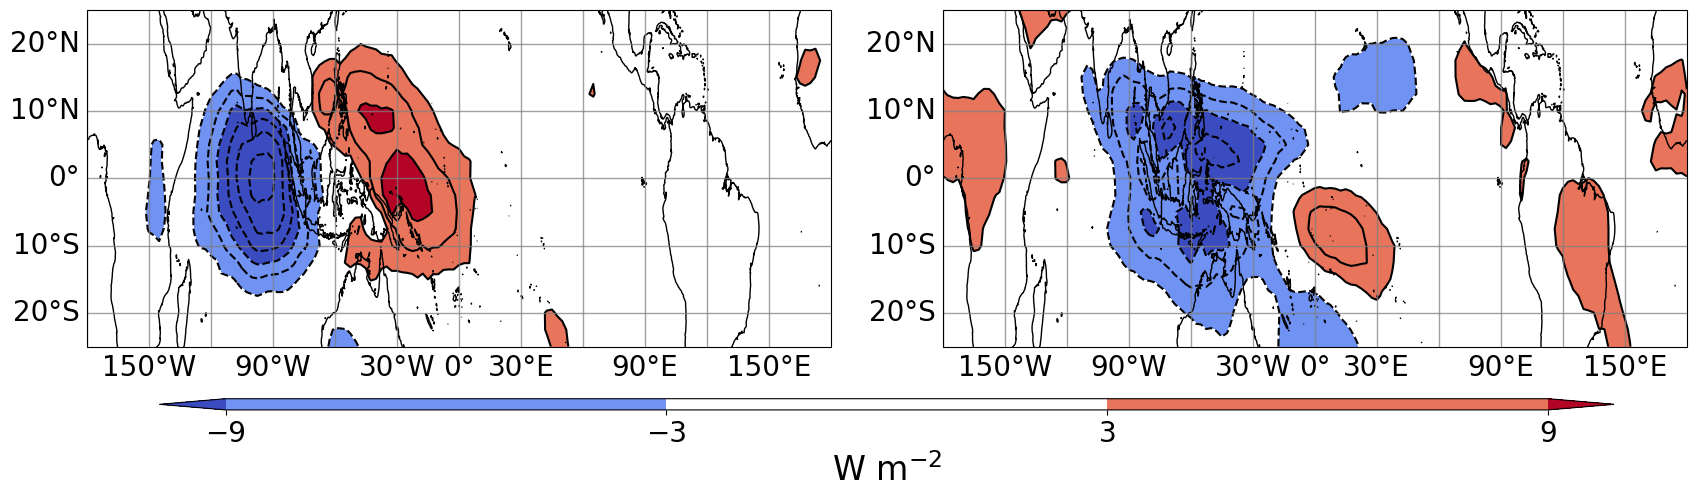

In [ ]:
# Set plotting parameters
output_directory = "output/mjo-compositing/"
plt.style.use('default')
plt.rcParams.update({'font.size':24})
cmap_modified = modified_colormap('coolwarm', 'white', 0.1, 0.1)
# cmap_modified = 'BrBG'
coastline_width = 1

fig = plt.figure(figsize=(16,4))
gs = GridSpec(2, 2, height_ratios=[30, 1], figure=fig)
gs.update(top=1, bottom=0, left=0, right=1, hspace=0.3, wspace=0.15)

proj = ccrs.PlateCarree(central_longitude=-180)
data_crs = ccrs.PlateCarree()

ax = [
    fig.add_subplot(gs[0,0], projection=proj),
    fig.add_subplot(gs[0,1], projection=proj)
]

cb_ax = fig.add_subplot(gs[1, :])

# Add cyclic point
cdata = xarray_utils.add_cyclic_point(
    model.scores().std(dim='time')*EOFs,
    dim='lon'
)

for index, mode in enumerate(EOFs.mode):
    # Plot data
    im = ax[index].contourf(
        cdata.lon, 
        cdata.lat, 
        cdata.sel(mode=mode), 
        transform=data_crs,
        cmap=cmap_modified,
        norm=mcolors.CenteredNorm(),
        levels=np.arange(-9, 9+6, 6),
        extend='both'
    )

    ax[index].contour(
        cdata.lon, 
        cdata.lat, 
        cdata.sel(mode=mode), 
        transform=data_crs,
        colors='k',
        levels=np.arange(-18, 18+3, 3)[np.arange(-18, 18+3, 3) != 0],
    )

    # Add colorbar
    cbar = fig.colorbar(im, cax=cb_ax, orientation='horizontal')
    cbar.ax.tick_params(labelsize=20)
    cbar.set_label(r'W m$^{-2}$')

    ax[index].set_aspect('auto')
    ax[index].set_xlabel('')
    # ax.set_global()
    ax[index].add_feature(cf.COASTLINE, lw=coastline_width)

    gl = ax[index].gridlines(
        crs=proj,
        draw_labels=True,
        linewidth=1,
        color="gray",
        alpha=0.75,
        linestyle="-",
        zorder=15

    )
    gl.right_labels = False
    gl.top_labels = False
    gl.xlocator = mticker.FixedLocator(np.arange(-180,180,30))
    # gl.xlocator = LongitudeLocator(30)
    gl.xformatter = LongitudeFormatter()
    gl.xlabel_style = {'fontsize':20}
    gl.ylocator = mticker.FixedLocator(np.arange(-40,40,10))
    gl.yformatter = LatitudeFormatter()
    gl.ylabel_style = {'fontsize':20}

plt.show()
# plt.savefig(f"{output_directory}/time_mean_OLR_zonal_wind_anomalies.png", dpi=300, bbox_inches='tight')

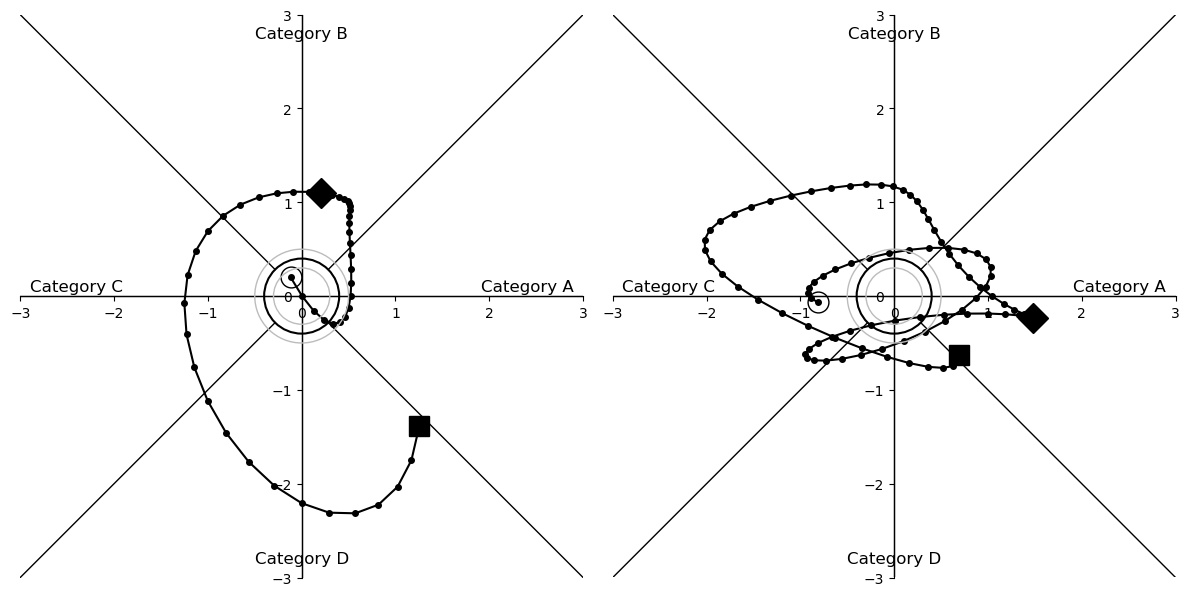

In [ ]:
# Configure plot
plt.style.use('default')
[fig, ax] = plt.subplots(1, 2, figsize=(12,6))
# plt.xlabel("RMM1")
# plt.ylabel("RMM2")

# Plot index points
colormap = sns.color_palette("viridis", as_cmap=True)

# start_time = '1992-02-12' 
# end_time = '1992-05-12'

# start_time = '1992-08-14' 
# end_time = '1992-11-12'

# start_time = np.datetime64("1975-04-01T00:00:00.000000000")
# end_time = np.datetime64("1975-04-30T00:00:00.000000000")

start_time = '1975-02-24T00:00:00.000000000'
end_time = '1975-04-11T00:00:00.000000000'

# for index, (start_time, end_time) in enumerate(zip(('1992-02-12', '1992-08-14'), ('1992-05-12', '1992-11-12'))):
for index, (start_time, end_time) in enumerate(zip((start_time, '1992-08-14'), (end_time, '1992-11-12'))):

    # Plot start_time as empty circle
    ax[index].plot(
        principle_components.sel(mode=1, time=start_time),
        principle_components.sel(mode=2, time=start_time),
        color="black",
        marker="o",
        markerfacecolor='None',
        ls="-",
        ms=15  
    )
    # Plot start_time as empty circle
    # ax[index].scatter(
    #     principle_components.sel(mode=1).where(a, drop=True),
    #     principle_components.sel(mode=2).where(a, drop=True),
    #     color="r",
    # )
    # ax[index].scatter(
    #     principle_components.sel(mode=1).where(b, drop=True),
    #     principle_components.sel(mode=2).where(b, drop=True),
    #     color="blue",
    # )
    # ax[index].scatter(
    #     principle_components.sel(mode=1).where(c, drop=True),
    #     principle_components.sel(mode=2).where(c, drop=True),
    #     color="yellow",
    # )
    # ax[index].scatter(
    #     principle_components.sel(mode=1).where(d, drop=True),
    #     principle_components.sel(mode=2).where(d, drop=True),
    #     color="green",
    # )
    # ax[index].scatter(
    #     principle_components.sel(mode=1).where(n, drop=True),
    #     principle_components.sel(mode=2).where(n, drop=True),
    #     color="purple",
    # )

    # Plot halfway point as filled diamond
    halfway_time = principle_components.sel(time=slice(start_time, end_time)).time.values[len(principle_components.sel(time=slice(start_time, end_time)).time) // 2]
    ax[index].plot(
        principle_components.sel(mode=1, time=halfway_time),
        principle_components.sel(mode=2, time=halfway_time),
        color="black",
        marker="D",
        markerfacecolor='black',
        ls="-",
        ms=15
    )

    ax[index].plot(
        principle_components.sel(mode=1, time=end_time),
        principle_components.sel(mode=2, time=end_time),
        color="black",
        marker="s",
        ls="-",
        ms=15    
    )
    # for time in principle_components.time.sel(time=slice(start_time, end_time)):
    ax[index].plot(
        principle_components.sel(mode=1, time=slice(start_time, end_time)),
        principle_components.sel(mode=2, time=slice(start_time, end_time)),
        color='k',
        linestyle='-',
        marker=".",
        ms=8,
    )

    # Add phase regions overlay
    circle1 = plt.Circle((0, 0), 0.3, color="#bcbcbc", fill=False, lw=1, zorder=10)
    circle2 = plt.Circle((0, 0), 0.4, color="k", fill=False, lw=1.5, zorder=10)
    circle3 = plt.Circle((0, 0), 0.5, color="#bcbcbc", fill=False, lw=1, zorder=10)
    ax[index].add_patch(circle1)
    ax[index].add_patch(circle2)
    ax[index].add_patch(circle3)

    ax[index].axhline(y=0, color="k", lw=1, ls="-")
    ax[index].axvline(x=0, color="k", lw=1, ls="-")

    # Add lines to differentiate the phases
    ax[index].plot(
        [0.4*np.cos(np.deg2rad(45)), 10*np.cos(np.deg2rad(45))],
        [0.4*np.sin(np.deg2rad(45)), 10*np.sin(np.deg2rad(45))],
        color="k",
        lw=1,
        ls="-"
    )
    ax[index].plot(
        [0.4*np.cos(np.deg2rad(45)), 10*np.cos(np.deg2rad(45))],
        [-0.4*np.sin(np.deg2rad(45)), -10*np.sin(np.deg2rad(45))],
        color="k",
        lw=1,
        ls="-"
    )
    ax[index].plot(
        [-0.4*np.cos(np.deg2rad(45)), -10*np.cos(np.deg2rad(45))],
        [-0.4*np.sin(np.deg2rad(45)), -10*np.sin(np.deg2rad(45))],
        color="k",
        lw=1,
        ls="-"
    )
    ax[index].plot(
        [-0.4*np.cos(np.deg2rad(45)), -10*np.cos(np.deg2rad(45))],
        [0.4*np.sin(np.deg2rad(45)), 10*np.sin(np.deg2rad(45))],
        color="k",
        lw=1,
        ls="-"
    )

    ax[index].set_xlim(-3,3)
    ax[index].set_ylim(-3,3)

    # # Add phase labels
    ax[index].text(
        2.9, 0.1,
        f'Category A',
        horizontalalignment='right',
        verticalalignment='center',
        fontsize=12
    )
    ax[index].text(
        0, 2.8,
        f'Category B',
        horizontalalignment='center',
        verticalalignment='center',
        fontsize=12
    )
    ax[index].text(
        -2.9, .1,
        f'Category C',
        horizontalalignment='left',
        verticalalignment='center',
        fontsize=12
    )
    ax[index].text(
        0, -2.8,
        f'Category D',
        horizontalalignment='center',
        verticalalignment='center',
        fontsize=12
    )

    ax[index].spines['left'].set_position('zero')
    ax[index].spines['bottom'].set_position('zero')

    # Hide the top and right spines
    ax[index].spines['right'].set_color('none')
    ax[index].spines['top'].set_color('none')

    # Ensure tick marks follow the spines to the center
    ax[index].xaxis.set_ticks_position('bottom')
    ax[index].yaxis.set_ticks_position('left')

    ax[index].set_aspect("equal")
plt.tight_layout()

In [ ]:
def get_category(principle_components, time):
    if np.sqrt(principle_components.sel(mode=1, time=time)**2 + principle_components.sel(mode=2, time=time)**2) <= 0.3:
        return 'N'
    elif (principle_components.sel(mode=1, time=time) > 0) and (principle_components.sel(mode=1, time=time) > np.abs(principle_components.sel(mode=2, time=time))):
        return 'A'
    elif (principle_components.sel(mode=2, time=time) > 0) and (principle_components.sel(mode=2, time=time) > np.abs(principle_components.sel(mode=1, time=time))):
        return 'B'
    elif (principle_components.sel(mode=1, time=time) < 0) and (-principle_components.sel(mode=1, time=time) > np.abs(principle_components.sel(mode=2, time=time))):
        return 'C'
    elif (principle_components.sel(mode=2, time=time) < 0) and(-principle_components.sel(mode=2, time=time) > np.abs(principle_components.sel(mode=1, time=time))):
        return 'D'


In [ ]:
import itertools

amplitude = np.sqrt(principle_components.sel(mode=1)**2 + principle_components.sel(mode=2)**2)

# start_time = np.datetime64("1990-01-01T00:00:00.000000000")
# end_time = np.datetime64("1990-12-31T00:00:00.000000000")

# start_time = np.datetime64("1975-01-01T00:00:00.000000000")
# end_time = np.datetime64("1975-12-31T00:00:00.000000000")

start_time = principle_components.isel(time=0).time.values
first_end = np.datetime64("1978-03-16")

second_start = np.datetime64("1979-01-01")
end_time = principle_components.isel(time=-1).time.values

# end_time = np.datetime64("1975-12-31T00:00:00.000000000")

# start_time = np.datetime64("1992-08-14T00:00:00.000000000")
# end_time = np.datetime64("1992-11-12T00:00:00.000000000")

# time_range_one = np.arange(start_time, first_end, np.timedelta64(1, 'D'))
# time_range_two = np.arange(second_start, end_time, np.timedelta64(1, 'D'))

time_range = np.arange(start_time, end_time, np.timedelta64(1, 'D'))

category = []
category.append(get_category(principle_components, principle_components.sel(time=start_time).time))

# for i, t in enumerate(itertools.chain(time_range_one, time_range_two)):
    if t == start_time:
        continue

    previous_category = get_category(principle_components, t-np.timedelta64(1, 'D'))
    nominal_category = get_category(principle_components, t)

    if amplitude.sel(time=t) < 0.3:
        category.append('N')
    elif amplitude.sel(time=t) > 0.5:
        category.append(nominal_category)
    else:
        if previous_category == 'N':
            category.append('N')
        else:
            category.append(nominal_category)

    # if previous_category == 'N' and amplitude.sel(time=t) < 0.5:
    #     category.append('N')
    #     # category[i] = 'N'
    # elif previous_category != 'N' and nominal_category == 'N' and amplitude.sel(time=t) > 0.3:
    #     category.append(previous_category)
    #     # category[i] = previous_category
    # else:
    #     category.append(nominal_category)
    #     # category[i] = nominal_category

categories = xr.DataArray(
    data=category,
    dims=['time'],
    coords={'time':np.concatenate((time_range_one, time_range_two))}
)

KeyError: "not all values found in index 'time'. Try setting the `method` keyword argument (example: method='nearest')."

In [ ]:
variables_filtered['Outgoing Longwave Radiation'].sel(time=categories[1146].time)

<xarray.DataArray (lat: 21, lon: 144)> Size: 24kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(21, 144))
Coordinates:
  * lon      (lon) float32 576B 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * lat      (lat) float32 84B -25.0 -22.5 -20.0 -17.5 ... 17.5 20.0 22.5 25.0
    time     datetime64[ns] 8B 1977-11-18
Attributes:
    units:         W/m^2
    var_desc:      Outgoing Longwave Radiation
    precision:     2
    dataset:       NOAA Interpolated OLR
    level_desc:    Other
    statistic:     Mean
    parent_stat:   Individual Obs
    valid_range:   [  0. 500.]
    long_name:     Daily Mean OLR
    actual_range:  [ 64.75 344.5 ]

In [ ]:
change_points = np.where(category.values[1:] != category.values[:-1])[0] + 1

collapsed_categories = np.concatenate(([category.values.astype(str)[0]], category.values.astype(str)[change_points]))
s= "".join(collapsed_categories)

pattern = "NABCD"
indices = []

start = 0
while True:
    i = s.find(pattern, start)
    if i == -1:
        break
    indices.append(i)
    start = i + 1   # allow overlapping matches


In [ ]:
import re

categories_string = "".join(categories.values.astype(str))
pattern = r"N+A+B+C+D+"
matches = list(re.finditer(pattern, categories_string))

# transition_indices = [m.start() for m in matches]
# transition_times = categories.time[transition_indices]

In [ ]:
# print(*categories.values, sep="\n")

principle_components.sel(time=categories[1146].time)

<xarray.DataArray 'scores' (mode: 2)> Size: 16B
array([nan, nan])
Coordinates:
    time     datetime64[ns] 8B 1977-11-18
  * mode     (mode) int64 16B 1 2
Attributes: (12/15)
    model:          EOF analysis
    software:       xeofs
    version:        3.0.4
    date:           2026-05-26 10:13:16
    n_modes:        2
    center:         True
    ...             ...
    sample_name:    sample
    feature_name:   feature
    random_state:   None
    compute:        True
    solver:         auto
    solver_kwargs:  {}

In [ ]:
test_str = "".join(category[4069:4125].values.astype('str'))
list(re.finditer(pattern, test_str))

In [ ]:
matches

In [ ]:
print(change_points[197])

print(category.isel(time=change_points[0]-1).values)
print(category.isel(time=change_points[0]).values)
print(category.isel(time=change_points[0]+1).values)
print(category.isel(time=change_points[0]+2).values)
print(category.isel(time=change_points[0]+3).values)

In [ ]:
# print(s[indices[0]-1])
# print(s[indices[0]])
# print(s[indices[0]+1])

collapsed_categories[195:205]
# collapsed_categories[197]

In [ ]:
# transition_times

print(get_category(principle_components, np.datetime64("1975-04-16T00:00:00.000000000")))
print(get_category(principle_components, np.datetime64("1975-04-17T00:00:00.000000000")))
print(get_category(principle_components, np.datetime64("1975-04-18T00:00:00.000000000")))

In [ ]:
indices

In [ ]:
get_category(principle_components, principle_components.isel(time=0).time)
for i, t in enumerate(time_range):
    print(f"{amplitude.sel(time=t).values:0.2f}, {category.sel(time=t).values:s}")

In [ ]:
t = principle_components.isel(time=4).time
nominal_category = get_category(principle_components, t)
previous_category = get_category(principle_components, t-np.timedelta64(1, 'D'))
next_category = get_category(principle_components, t+np.timedelta64(1, 'D'))

print(previous_category, nominal_category, next_category)

In [ ]:

matthews = 'CDABCDABCDABCDNABCDANCNADNCBADCNABCDANABC'

In [ ]:
for i in range(0, 10):
    print(t.values)
    t = category.isel(time=i).time
    nominal_category = get_category(principle_components, t)
    previous_category = get_category(principle_components, t-np.timedelta64(1, 'D'))
    next_category = get_category(principle_components, t+np.timedelta64(1, 'D'))

    print(previous_category, nominal_category, next_category, amplitude.sel(time=t).values)

In [ ]:
# amplitude.sel(time="1997-08-17T00:00:00.000000000")
get_category(principle_components, principle_components.sel(time="1997-08-17T00:00:00.000000000").time)

In [ ]:
# category.isel(time=slice(0, 10))
# print(get_category(principle_components, principle_components.time[0]))
# print(principle_components[:,0].values)
category.sel(time="1992-08-14")

In [ ]:
i = 2684
print(get_category(principle_components, i))
print(principle_components.isel(time=i).values)

In [ ]:
principle_components.isel(time=0)